In [1]:
from RNAFoldAssess.models.scorers import EternaScorer

In [2]:
import data_utils as du

def detect_dataset(line):
    ds = line[0]
    if ds == "RNAndria":
        if line[2].startswith("hsa"):
            return "RNAndria miRNA"
        else:
            return "RNAndria mRNA"
    else:
        return ds

with open("data/chemical_mapping_master_file.txt") as fh:
    dsci_data = fh.readlines()

dsci_data = [d.split(", ") for d in dsci_data]


dsci_data[0]

['EternaData',
 'ContextFold',
 'ETOBCR_VN1_0001_ANNOTATION_1',
 'GGUGGUAUUCUAAGCGAUGGUGAAACUACUAUUGGGCUUUCUACUCUUAGAUGGUCGUGUUGAUUGCAAUCAACACCUUAGAGUAAAAGAAACAACAACAACAAC',
 '.((.....((((((.(..((.....(((....))).....)).).)))))).....(((((((......)))))))........................))...',
 '0.5743243243243243\n']

In [5]:
unique_dps = list(set([line[2] for line in dsci_data]))

In [ ]:
import csv

base_path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data"
eterna_path = f"{base_path}/eterna_score_by_model_eterna_data.csv"
rnandria_human_path = f"{base_path}/eterna_score_by_model_rnandria_data.csv"
rnandria_pri_path = f"{base_path}/eterna_score_by_model_rnandria_pri_data.csv"
ribo_path = f"{base_path}/eterna_score_by_model_ribo_data.csv"

score_paths = [eterna_path, rnandria_human_path, rnandria_pri_path, ribo_path]

dp_model_map = {}
for p in score_paths:
    with open(p) as fh:
        eterna_score_data = csv.DictReader(fh)

        for row in eterna_score_data:
            dp = row["datapoint"]
            dp_model_map[dp] = {"dataset": None}
            for m in du.models:
                eterna_score = row[m]
                eterna_score = float(eterna_score)
                dp_model_map[dp][m] = {"eterna_score": eterna_score}

    for line in dsci_data:
        ds = detect_dataset(line)
        if ds == "YesselmanLab":
            continue
        model = line[1]
        dp = line[2]
        if dp not in dp_model_map:
            continue
        stc = line[4]
        dsci_score = float(line[5].strip())
        dp_model_map[dp]["dataset"] = ds
        dp_model_map[dp][model]["dsci_score"] = dsci_score


FileNotFoundError: [Errno 2] No such file or directory: '/Users/erikwhiting/src/RNAFoldAssess/data/all_data/eterna_score_by_model_ribo_data.csv '

In [24]:
dp_model_map["ETOBCR_VN1_0001_ANNOTATION_1"]

{'dataset': 'EternaData',
 'ContextFold': {'eterna_score': 0.5396825396825397,
  'dsci_score': 0.5743243243243243},
 'ContraFold': {'eterna_score': 0.7777777777777778,
  'dsci_score': 0.5788409703504043},
 'EternaFold': {'eterna_score': 0.7777777777777778,
  'dsci_score': 0.5788409703504043},
 'IPKnot': {'eterna_score': 0.5238095238095238,
  'dsci_score': 0.4852941176470588},
 'MXFold': {'eterna_score': 0.746031746031746,
  'dsci_score': 0.5606617647058824},
 'MXFold2': {'eterna_score': 0.7777777777777778,
  'dsci_score': 0.5788409703504043},
 'NeuralFold': {'eterna_score': 0.4444444444444444,
  'dsci_score': 0.5564516129032258},
 'NUPACK': {'eterna_score': 0.7777777777777778,
  'dsci_score': 0.5788409703504043},
 'pKnots': {'eterna_score': 0.7777777777777778,
  'dsci_score': 0.5788409703504043},
 'RNAFold': {'eterna_score': 0.7777777777777778,
  'dsci_score': 0.5788409703504043},
 'RNAStructure': {'eterna_score': 0.7777777777777778,
  'dsci_score': 0.5788409703504043},
 'Simfold': {'e

In [26]:
model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

def has_all_scores(datapoint_results):
    for model in model_order:
        if model not in datapoint_results:
            return False

        model_scores = datapoint_results[model]

        for score in ["eterna_score", "dsci_score"]:
            if score not in model_scores:
                return False

            if model_scores[score] is None:
                return False

    return True

In [30]:
fstring = "datapoint,dataset,model,eterna_score,dsci_score\n"

for datapoint_id, datapoint_results in dp_model_map.items():
    if not has_all_scores(datapoint_results):
        continue

    dataset = datapoint_results["dataset"]
    for m in model_order:
        line = f"{datapoint_id},{dataset},{m},"
        eterna_score = str(datapoint_results[m]["eterna_score"])
        dsci_score = str(datapoint_results[m]["dsci_score"])
        line += f"{eterna_score},{dsci_score}\n"
        fstring += line

    fstring.strip() # Remove last newline character

with open("data/chem_mapping_eterna_vs_dsci_scores.csv", "w") as fh:
    fh.write(fstring)


/var/folders/1f/c4zwfcn929qgw6shcb4frpjm0000gn/T/ipykernel_3307/1167926991.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/erikwhiting/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


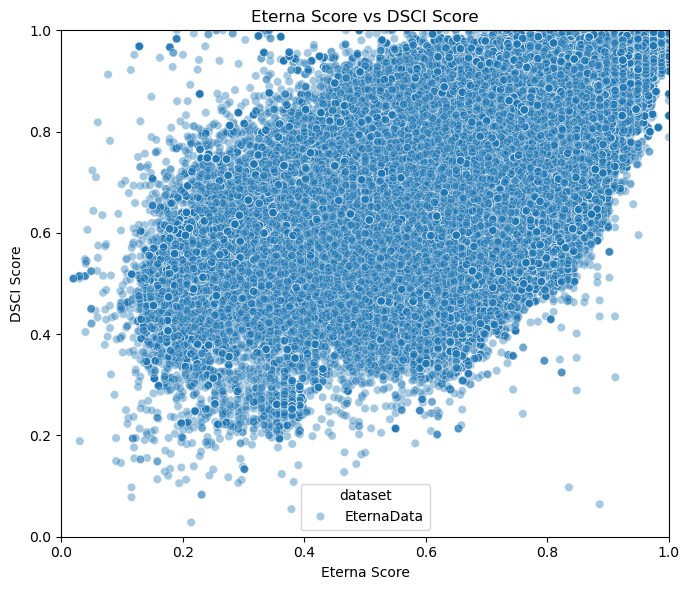

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/chem_mapping_eterna_vs_dsci_scores.csv")

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df,
    x="eterna_score",
    y="dsci_score",
    hue="dataset",
    alpha=0.4
)

plt.xlabel("Eterna Score")
plt.ylabel("DSCI Score")
plt.title("Eterna Score vs DSCI Score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [33]:
# Spearman correlation:
print("Overall correlation")
overall_corr = df[["eterna_score", "dsci_score"]].corr(method="spearman")
print(overall_corr)

print("Spearman correlation by dataset")
dataset_corr = (
    df.groupby("dataset")
      .apply(lambda g: g["eterna_score"].corr(g["dsci_score"], method="spearman"))
      .reset_index(name="spearman_corr")
)

print(dataset_corr)

print("Spearman correlation by model")
model_corr = (
    df.groupby("model")
      .apply(lambda g: g["eterna_score"].corr(g["dsci_score"], method="spearman"))
      .reset_index(name="spearman_corr")
)

print(model_corr)

Overall correlation
              eterna_score  dsci_score
eterna_score      1.000000    0.675155
dsci_score        0.675155    1.000000
Spearman correlation by dataset
      dataset  spearman_corr
0  EternaData       0.675155
Spearman correlation by model
           model  spearman_corr
0    ContextFold       0.638904
1     ContraFold       0.676580
2     EternaFold       0.694714
3         IPKnot       0.607602
4         MXFold       0.692492
5        MXFold2       0.684549
6         NUPACK       0.676388
7     NeuralFold       0.613958
8        RNAFold       0.707715
9   RNAStructure       0.704219
10      SPOT-RNA       0.650909
11       Simfold       0.714843
12        pKnots       0.688288


/var/folders/1f/c4zwfcn929qgw6shcb4frpjm0000gn/T/ipykernel_3307/2119198108.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["eterna_score"].corr(g["dsci_score"], method="spearman"))
/var/folders/1f/c4zwfcn929qgw6shcb4frpjm0000gn/T/ipykernel_3307/2119198108.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["eterna_score"].corr(g["dsci_score"], method="spearman"))


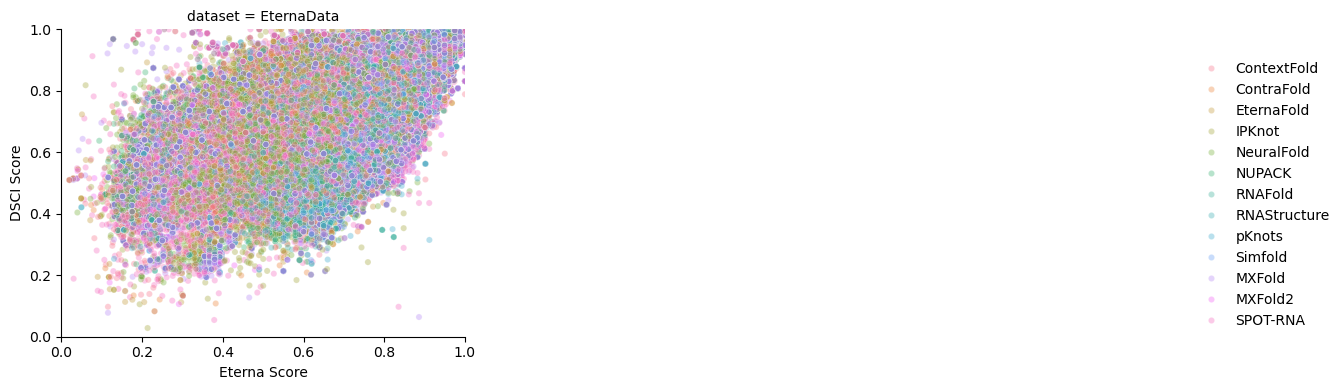

In [34]:
g = sns.FacetGrid(
    df,
    col="dataset",
    col_wrap=3,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="eterna_score",
    y="dsci_score",
    hue="model",
    alpha=0.35,
    s=20
)

g.set_axis_labels("Eterna Score", "DSCI Score")
g.set(xlim=(0, 1), ylim=(0, 1))
g.add_legend()

plt.tight_layout()
plt.show()